In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
tickers = ["SAN.PA", "NOVN.SW", "AIR.PA", "NVDA", "CW8.PA"]

portefeuille = yf.download(tickers, start="2021-08-01", end="2026-08-01")["Close"]

print(portefeuille.shape)
print(portefeuille.isna().sum())
portefeuille.head()

[*********************100%***********************]  5 of 5 completed

(1293, 5)
Ticker
AIR.PA     12
CW8.PA     12
NOVN.SW    36
NVDA       38
SAN.PA     12
dtype: int64


Ticker,AIR.PA,CW8.PA,NOVN.SW,NVDA,SAN.PA
Date,,,,,
2021-08-02,107.138069,393.932800,65.695908,19.659922,70.015121
2021-08-03,105.303200,393.200012,65.468475,19.724623,69.772995
2021-08-04,104.991280,395.166107,65.366531,20.181532,68.199173
2021-08-05,107.009628,396.690613,65.327309,20.542877,68.699562
2021-08-06,107.248169,399.037689,65.484161,20.273113,69.611588


In [3]:
portefeuille = portefeuille.ffill()
print(portefeuille.isna().sum())

Ticker
AIR.PA     0
CW8.PA     0
NOVN.SW    0
NVDA       0
SAN.PA     0
dtype: int64


In [4]:
rendements = portefeuille.pct_change().dropna()
rendements.head()

Ticker,AIR.PA,CW8.PA,NOVN.SW,NVDA,SAN.PA
Date,,,,,
2021-08-03,-0.017126,-0.001860,-0.003462,0.003291,-0.003458
2021-08-04,-0.002962,0.005000,-0.001557,0.023164,-0.022556
2021-08-05,0.019224,0.003858,-0.000600,0.017905,0.007337
2021-08-06,0.002229,0.005917,0.002401,-0.013132,0.013276
2021-08-09,-0.018306,0.001322,0.013772,-0.003486,0.009275


In [5]:
vol = rendements.std() * (252 ** 0.5)
print(vol.sort_values(ascending=False))

Ticker
NVDA       0.511266
AIR.PA     0.285274
SAN.PA     0.232093
NOVN.SW    0.178100
CW8.PA     0.140472
dtype: float64


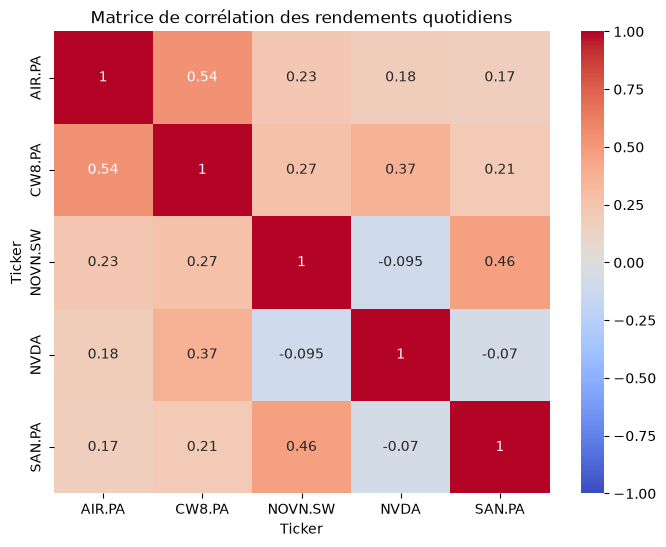

In [6]:
correlations = rendements.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlations, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Matrice de corrélation des rendements quotidiens")
plt.show()

In [7]:
poids = 0.25
rendement_ptf = (rendements[["SAN.PA", "NOVN.SW", "AIR.PA", "NVDA"]] * poids).sum(axis=1)

vol_ptf = rendement_ptf.std() * (252 ** 0.5)
moyenne_vols = vol[["SAN.PA", "NOVN.SW", "AIR.PA", "NVDA"]].mean()

print("Volatilité du portefeuille :", vol_ptf)
print("Moyenne des volatilités   :", moyenne_vols)

Volatilité du portefeuille : 0.18197896325526908
Moyenne des volatilités   : 0.3016833168958872


In [13]:
taux_sans_risque = 0.03
rendement_ann = rendement_ptf.mean() * (252)
sharpe = (rendement_ann - taux_sans_risque)/(vol_ptf)

print("Rendement annuel :", rendement_ann)
print("Ratio de Sharpe :", sharpe)

Rendement annuel : 0.23268038918820202
Ratio de Sharpe : 1.1137572473357498


In [14]:
portefeuille["NVDA"].iloc[-1] / portefeuille["NVDA"].iloc[0] - 1

np.float64(9.199716108554764)

In [33]:
marche = rendements["CW8.PA"]
for ticker in ["SAN.PA", "NOVN.SW", "AIR.PA", "NVDA"]:

    beta = rendements[ticker].cov(marche)/marche.var()

    print("Beta :", beta)

Beta : 0.34619017713156597
Beta : 0.33896078968491844
Beta : 1.087905771663578
Beta : 1.3384767837543978


## Conclusion : l'effet diversification

**Résultat :** un portefeuille réparti à 25 % sur SAN, NOVN, AIR et NVDA a une volatilité de **18,2 %**, alors que la moyenne des volatilités de ces quatre titres est de **30,2 %**. Le risque baisse de 40 %.

**Pourquoi :** les quatre titres sont peu corrélés (entre −0,1 et 0,46), c'est-à-dire qu'ils ne montent et ne baissent pas en même temps. Leurs mouvements se compensent en partie, ce qui lisse le résultat global.

**À retenir :**
- Le rendement d'un portefeuille est la moyenne des rendements.
- Le risque d'un portefeuille est **inférieur** à la moyenne des risques, sauf si tous les titres bougent exactement ensemble (corrélation de 1).
- Ce n'est pas le nombre de titres qui réduit le risque, c'est leur faible corrélation.

## Ratio de Sharpe : lecture critique

**Résultat :** rendement annualisé de 23,3 %, volatilité de 18,2 %, taux sans risque de 3 %, soit un **Sharpe de 1,11**. Au-dessus de 1, c'est un très bon ratio : chaque point de risque pris a rapporté 1,11 point de rendement au-delà du taux sans risque.

**Mais ce chiffre est trop flatteur :**

- **Biais de sélection** : les titres ont été choisis en 2026, en sachant déjà que Nvidia avait été multipliée par 10 sur la période (+920 %). Un investisseur de 2021 ne le savait pas.
- **Période favorable** : 2021-2026 a été globalement porteuse pour les actions. Sur une période avec un krach, le Sharpe serait bien plus modeste.
- **Taux sans risque hypothétique** : le 3 % est une hypothèse. Le vrai taux a varié de 0 % à environ 4 % sur la période, ce qui fait bouger le Sharpe entre environ 1,06 et 1,28.

**À retenir :** un calcul juste ne fait pas une conclusion valide.

## Bêta : sensibilité au marché (référence : CW8)

**Résultats :** SAN 0,35 / NOVN 0,34 / AIR 1,09 / NVDA 1,34

- **Pharmas (SAN, NOVN)** : bêta très inférieur à 1, donc titres **défensifs**, peu dépendants de la conjoncture.
- **Airbus** : bêta proche de 1, donc titre **cyclique**, qui suit l'économie mondiale.
- **Nvidia** : bêta supérieur à 1, donc il **amplifie** les mouvements du marché.

**Le bêta n'est pas la volatilité.** Sanofi a une volatilité de 23 % (supérieure à celle du marché, 14 %) mais un bêta de seulement 0,35 : elle bouge beaucoup, mais surtout pour des raisons qui lui sont propres (brevets, essais cliniques, résultats). La volatilité mesure le risque **total**, le bêta seulement la part **liée au marché**.

**Limite :** CW8 cote à Paris (fermeture 17h30), Nvidia à New York (fermeture 22h). Une partie des mouvements de Nvidia n'apparaît dans CW8 que le lendemain, ce qui sous-estime sa corrélation (0,37) et probablement son bêta.